In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from datetime import datetime

In [2]:
car_df = pd.read_csv('/content/Cardetails.csv')

In [3]:
car_df.shape

(8128, 13)

In [4]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
car_df.drop(columns=['torque'],inplace=True)

In [6]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [7]:
car_df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [8]:
car_df = car_df.dropna(how='any')

In [9]:
car_df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [10]:
car_df.shape

(7907, 12)

In [11]:
car_df.duplicated().sum()

np.int64(1189)

In [12]:
car_df = car_df.drop_duplicates().reset_index(drop=True)

In [13]:
car_df.shape

(6718, 12)

In [14]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6718 entries, 0 to 6717
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   object 
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   object 
 5   seller_type    6718 non-null   object 
 6   transmission   6718 non-null   object 
 7   owner          6718 non-null   object 
 8   mileage        6718 non-null   object 
 9   engine         6718 non-null   object 
 10  max_power      6718 non-null   object 
 11  seats          6718 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 629.9+ KB


In [15]:
#unique value of each column
for col in car_df.columns:
  print('Unique values of ' + col)
  print(car_df[col].unique())
  print('===============\n')

Unique values of name
['Maruti Swift Dzire VDI' 'Skoda Rapid 1.5 TDI Ambition'
 'Honda City 2017-2020 EXi' ... 'Tata Nexon 1.5 Revotorq XT'
 'Ford Freestyle Titanium Plus Diesel BSIV'
 'Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV']

Unique values of year
[2014 2006 2010 2007 2017 2001 2011 2013 2005 2009 2016 2012 2002 2015
 2018 2019 2008 2020 1999 2000 2003 2004 1994 1998 1997 1995 1996]

Unique values of selling_price
[  450000   370000   158000   225000   130000   440000    96000    45000
   350000   200000   500000    92000   280000   180000   400000   778000
   150000   680000   174000   950000   525000   600000   575000   275000
   300000   220000   254999   670000   730000   650000   330000   366000
  1149000   425000  2100000   925000   675000   819999   390000  1500000
   700000  1450000  1090000   850000  1650000  1750000  1590000  1689999
  1425000   265000   190000   630000   540000   448000   745000  1025000
   235000  1700000  1200000   610000  2500000   484999   315000

In [16]:
car_df['name'] = car_df['name'].str.lower().str.strip()

In [17]:
car_df['brand'] = car_df['name'].apply(lambda x: x.split()[0])

In [18]:
car_df['model_name'] = car_df['name'].apply(lambda x: ' '.join(x.split()[1:]))

In [19]:
current_year = datetime.now().year

In [20]:
car_df['car_age'] = current_year - car_df['year']

In [21]:
car_df['km_per_year'] = car_df['km_driven'] / (car_df['car_age'] + 1)

In [22]:
print(car_df[['max_power', 'engine']].dtypes)

max_power    object
engine       object
dtype: object


In [23]:
car_df.drop(columns=['name','year'],inplace=True)

In [24]:
def get_1st(value):
  try:
    return float(str(value).strip().split()[0])
  except:
    return 0

In [25]:
print(car_df['brand'].iloc[0])

maruti


In [26]:
print(car_df['model_name'].iloc[0])

swift dzire vdi


In [27]:
car_df['brand'].unique()

array(['maruti', 'skoda', 'honda', 'hyundai', 'toyota', 'ford', 'renault',
       'mahindra', 'tata', 'chevrolet', 'datsun', 'jeep', 'mercedes-benz',
       'mitsubishi', 'audi', 'volkswagen', 'bmw', 'nissan', 'lexus',
       'jaguar', 'land', 'mg', 'volvo', 'daewoo', 'kia', 'fiat', 'force',
       'ambassador', 'ashok', 'isuzu', 'opel'], dtype=object)

In [28]:
car_df['model_name'].unique()

array(['swift dzire vdi', 'rapid 1.5 tdi ambition', 'city 2017-2020 exi',
       ..., 'nexon 1.5 revotorq xt',
       'freestyle titanium plus diesel bsiv',
       'innova 2.5 gx (diesel) 8 seater bs iv'], dtype=object)

In [29]:
car_df['mileage'] = car_df['mileage'].apply(get_1st)

In [30]:
car_df['engine'] = car_df['engine'].apply(get_1st)

In [31]:
car_df['max_power'] = car_df['max_power'].apply(get_1st)

In [32]:
print(car_df[['max_power', 'engine']].dtypes)

max_power    float64
engine       float64
dtype: object


In [33]:
car_df['max_power'] = pd.to_numeric(car_df['max_power'])
car_df['engine'] = pd.to_numeric(car_df['engine'])

In [34]:
car_df['power_per_cc'] = car_df['max_power'] / car_df['engine']

In [35]:
print(car_df.dtypes)

selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
brand             object
model_name        object
car_age            int64
km_per_year      float64
power_per_cc     float64
dtype: object


In [36]:
for col in car_df.columns:
  print('Unique values of ' + col)
  print(car_df[col].unique())
  print('===============\n')

Unique values of selling_price
[  450000   370000   158000   225000   130000   440000    96000    45000
   350000   200000   500000    92000   280000   180000   400000   778000
   150000   680000   174000   950000   525000   600000   575000   275000
   300000   220000   254999   670000   730000   650000   330000   366000
  1149000   425000  2100000   925000   675000   819999   390000  1500000
   700000  1450000  1090000   850000  1650000  1750000  1590000  1689999
  1425000   265000   190000   630000   540000   448000   745000  1025000
   235000  1700000  1200000   610000  2500000   484999   315000   290000
   455000   351000   535000   175000   565000   120000   725000   185000
   615000   270000   625000   866000   375000   522000   451999   475000
   780000   595000  1140000   360000   105000   135000   690000  3975000
  5150000  3200000  4100000  4500000  6000000  3790000  5800000  1864999
  2700000   795000  3400000  2650000  5850000   975000   805000  2625000
   811000   550000  

In [37]:
car_df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand,model_name,car_age,km_per_year,power_per_cc
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,maruti,swift dzire vdi,12,11192.307692,0.059295
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,skoda,rapid 1.5 tdi ambition,12,9230.769231,0.069105
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,honda,city 2017-2020 exi,20,6666.666667,0.052104
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,hyundai,i20 sportz diesel,16,7470.588235,0.064470
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,maruti,swift vxi bsiii,19,6000.000000,0.067951


In [38]:
car_df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [39]:
car_df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [40]:
car_df['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [41]:
car_df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [42]:
#encoders = {}
#cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand','model_name']
#for col in cols:
#  le = LabelEncoder()
#  car_df[col] = le.fit_transform(car_df[col])
#  encoders[col] = le

In [43]:
#installing target encoder
!pip install category_encoders

In [44]:
import category_encoders as ce

In [45]:
car_df

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand,model_name,car_age,km_per_year,power_per_cc
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,maruti,swift dzire vdi,12,11192.307692,0.059295
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,skoda,rapid 1.5 tdi ambition,12,9230.769231,0.069105
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,honda,city 2017-2020 exi,20,6666.666667,0.052104
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,hyundai,i20 sportz diesel,16,7470.588235,0.064470
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,maruti,swift vxi bsiii,19,6000.000000,0.067951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6713,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,5.0,maruti,wagon r vxi bs iv with abs,13,3571.428571,0.067234
6714,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0,hyundai,i20 magna 1.4 crdi,12,6153.846154,0.063560
6715,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0,hyundai,i20 magna,13,7857.142857,0.069215
6716,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0,hyundai,verna crdi sx,19,5950.000000,0.073677


In [46]:
#for col in cols:
#    print(col)
#    print(dict(zip(encoders[col].classes_,
#                   encoders[col].transform(encoders[col].classes_))))
#    print()

In [47]:
X = car_df.drop(columns=['selling_price'])
Y = car_df['selling_price']

In [48]:
encoder = ce.TargetEncoder(
    cols=['fuel', 'seller_type', 'transmission',
          'owner', 'brand', 'model_name']
)

In [49]:
X = encoder.fit_transform(X, Y)

In [50]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

XGBoost

In [52]:
from xgboost import XGBRegressor

In [53]:
xg_model = XGBRegressor()

In [54]:
xg_model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [55]:
X_train_pred_xg = xg_model.predict(X_train)
X_test_pred_xg = xg_model.predict(X_test)

In [56]:
#R squared error
score_13 = r2_score(Y_train,X_train_pred_xg)
print("Training Data R squared error : ",score_13)
#Mean Absolute Error
score_14 = mean_absolute_error(Y_train,X_train_pred_xg)
print("Training Data Mean Absolute Error : ",score_14)
#Root mean squared error
score_15 = np.sqrt(mean_squared_error(Y_train,X_train_pred_xg))
print("Training Data Root Mean Squared Error : ",score_15)

Training Data R squared error :  0.9949331283569336
Training Data Mean Absolute Error :  28788.513671875
Training Data Root Mean Squared Error :  38883.05666996873


In [57]:
# TESTING DATA
#R squared error
score_16 = r2_score(Y_test,X_test_pred_xg)
print("Testing Data R squared error : ",score_16)
#Mean Absolute Error
score_17 = mean_absolute_error(Y_test,X_test_pred_xg)
print("Testing Data Mean Absolute Error : ",score_17)
#Root mean squared error
score_18 = np.sqrt(mean_squared_error(Y_test,X_test_pred_xg))
print("Testing Data Root Mean Squared Error : ",score_18)

Testing Data R squared error :  0.9251722097396851
Testing Data Mean Absolute Error :  60839.203125
Testing Data Root Mean Squared Error :  114830.93771279584


Random Forest

In [58]:
rf_model = RandomForestRegressor()

In [59]:
rf_model.fit(X_train,Y_train)

RandomForestRegressor()

In [60]:
train_score = rf_model.score(X_train, Y_train)
test_score = rf_model.score(X_test, Y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9927925124205603
Test Score: 0.9357846452483561


In [61]:
X_train_pred_rf = rf_model.predict(X_train)
X_test_pred_rf = rf_model.predict(X_test)

In [62]:
#R squared error
score_1 = r2_score(Y_train,X_train_pred_rf)
print("Training Data R squared error : ",score_1)
#Mean Absolute Error
score_2 = mean_absolute_error(Y_train,X_train_pred_rf)
print("Training Data Mean Absolute Error : ",score_2)
#Root mean squared error
score_3 = np.sqrt(mean_squared_error(Y_train,X_train_pred_rf))
print("Training Data Root Mean Squared Error : ",score_3)

Training Data R squared error :  0.9927925124205603
Training Data Mean Absolute Error :  23482.17732134292
Training Data Root Mean Squared Error :  46374.809430262314


In [63]:
# TESTING DATA
#R squared error
score_4 = r2_score(Y_test,X_test_pred_rf)
print("Testing Data R squared error : ",score_4)
#Mean Absolute Error
score_5 = mean_absolute_error(Y_test,X_test_pred_rf)
print("Testing Data Mean Absolute Error : ",score_5)
#Root mean squared error
score_6 = np.sqrt(mean_squared_error(Y_test,X_test_pred_rf))
print("Testing Data Root Mean Squared Error : ",score_6)

Testing Data R squared error :  0.9357846452483561
Testing Data Mean Absolute Error :  59144.61738626111
Testing Data Root Mean Squared Error :  106376.77225612124


Linear Regression

In [64]:
lr_model = LinearRegression()

In [65]:
lr_model.fit(X_train,Y_train)

LinearRegression()

In [66]:
X_train_pred_lr = lr_model.predict(X_train)
X_test_pred_lr = lr_model.predict(X_test)

In [67]:
# TRAINING DATA
#R squared error
score_7 = r2_score(Y_train,X_train_pred_lr)
print("Training Data R squared error : ",score_7)
#Mean Absolute Error
score_8 = mean_absolute_error(Y_train,X_train_pred_lr)
print("Training Data Mean Absolute Error : ",score_8)
#Root mean squared error
score_9 = np.sqrt(mean_squared_error(Y_train,X_train_pred_lr))
print("Training Data Root Mean Squared Error : ",score_9)

Training Data R squared error :  0.7717149325194727
Training Data Mean Absolute Error :  161006.470759307
Training Data Root Mean Squared Error :  260993.04773880346


In [68]:
# TESTING DATA
#R squared error
score_10 = r2_score(Y_test,X_test_pred_lr)
print("Testing Data R squared error : ",score_10)
#Mean Absolute Error
score_11 = mean_absolute_error(Y_test,X_test_pred_lr)
print("Testing Data Mean Absolute Error : ",score_11)
#Root mean squared error
score_12 = np.sqrt(mean_squared_error(Y_test,X_test_pred_lr))
print("Testing Data Root Mean Squared Error : ",score_12)

Testing Data R squared error :  0.7419812186054682
Testing Data Mean Absolute Error :  152023.81017803476
Testing Data Root Mean Squared Error :  213232.31669648684


In [69]:
# The values of R2 , MAE and RMSE of Random Forest are very much lesser than Linear Regression .
# LR fails here because the relationship between features and prices are not linear .

### Making Predictive System

In [70]:
print(X.columns)

Index(['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage',
       'engine', 'max_power', 'seats', 'brand', 'model_name', 'car_age',
       'km_per_year', 'power_per_cc'],
      dtype='object')


In [71]:
km = 5000
fuel = 'Petrol'.lower().strip()
seller = 'Individual'.lower().strip()
transmission = 'automatic'.lower().strip()
owner = 'first owner'.lower().strip()
age = 7
max_power = 160
engine = 1368
mileage = 16
seats = 5
brand = 'Jeep'.lower().strip()
model = 'Compass 1.4 Limited Plus BSIV'.lower().strip()
km_per_year = km / (age + 1)
power_per_cc = max_power / engine

In [72]:
new_data = pd.DataFrame({
    'km_driven': [km],
    'fuel': [fuel],
    'seller_type': [seller],
    'transmission': [transmission],
    'owner': [owner],
    'mileage': [mileage],
    'engine': [engine],
    'max_power': [max_power],
    'seats': [seats],
    'brand': [brand],
    'model_name': [model],
    'car_age': [12],
    'km_per_year': [km_per_year],
    'power_per_cc': [power_per_cc]
})

In [73]:
new_data = encoder.transform(new_data)

In [74]:
prediction = rf_model.predict(new_data)
print("Predicted price:", round(prediction[0], 2))

Predicted price: 1898609.98


### Feature Importance Graph

In [75]:
feature_importance = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

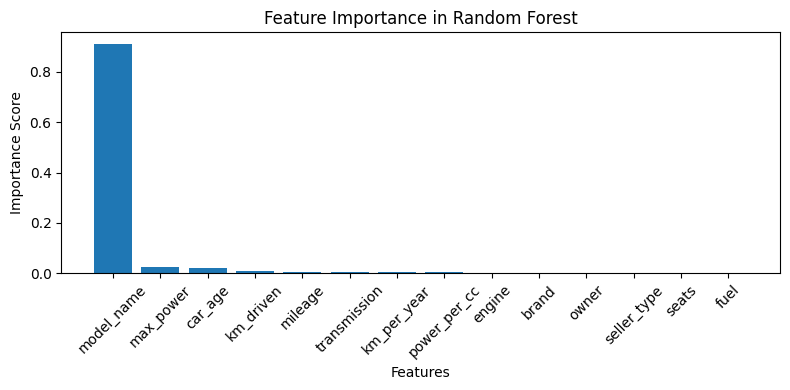

In [76]:
plt.figure(figsize=(8,4))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Random Forest")
plt.tight_layout()
plt.show()

In [77]:
print(importance_df)

         Feature  Importance
10    model_name    0.911311
7      max_power    0.026177
11       car_age    0.022162
0      km_driven    0.007544
5        mileage    0.007239
3   transmission    0.005407
12   km_per_year    0.005155
13  power_per_cc    0.004674
6         engine    0.003378
9          brand    0.003114
4          owner    0.001944
2    seller_type    0.000871
8          seats    0.000750
1           fuel    0.000272
